# Convolutional Neural Networks (CNNs) — Implementation Notebook

## Part 2: TensorFlow / Keras — LeNet-Style CNN

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix


mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [2]:

rows, cols = 28, 28

# Reshape the data into a 4D Array
x_train = x_train.reshape(x_train.shape[0], rows, cols, 1)
x_test = x_test.reshape(x_test.shape[0], rows, cols, 1)
print(x_train.shape)
input_shape = (rows, cols, 1) 

# Set type as float32 and normalize the values to [0,1]
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train = x_train / 255.0
x_test = x_test / 255.0

# Save original labels for confusion matrix
y_test_labels = y_test.copy()

# Transform labels to one hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


(60000, 28, 28, 1)


In [3]:
def build_lenet(input_shape):
    model = tf.keras.Sequential()
    
    # C1 Convolution Layer
    model.add(tf.keras.layers.Conv2D(filters=6, strides=(1,1), kernel_size=(5,5), activation='tanh', input_shape=input_shape))
    
    # S2 SubSampling Layer
    model.add(tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))

    # C3 Convolution Layer
    model.add(tf.keras.layers.Conv2D(filters=16, strides=(1,1), kernel_size=(5,5), activation='tanh'))

    # S4 SubSampling Layer
    model.add(tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))

    # Flatten the output
    model.add(tf.keras.layers.Flatten())

    # C5 Fully Connected Layer
    model.add(tf.keras.layers.Dense(units=120, activation='tanh'))

    # FC6 Fully Connected Layers
    model.add(tf.keras.layers.Dense(units=84, activation='tanh'))

    # Output Layer
    model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

    # Compile the Model 
    model.compile(
        loss='categorical_crossentropy', 
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.0), 
        metrics=['accuracy']
    )

    return model

lenet = build_lenet(input_shape)

c:\Users\Muhammad Huzifa\anaconda3\envs\deepenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Train the model
epochs = 10
history = lenet.fit(x_train, y_train, epochs=epochs, batch_size=128, verbose=1, validation_data=(x_test, y_test))

# Evaluate the model
loss, acc = lenet.evaluate(x_test, y_test, verbose=0)
print(f'\nTest Accuracy: {acc:.4f}')
print(f'Test Loss: {loss:.4f}')


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8826 - loss: 0.4179 - val_accuracy: 0.9374 - val_loss: 0.2136
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9468 - loss: 0.1756 - val_accuracy: 0.9622 - val_loss: 0.1299
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9646 - loss: 0.1189 - val_accuracy: 0.9723 - val_loss: 0.0951
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9727 - loss: 0.0897 - val_accuracy: 0.9765 - val_loss: 0.0791
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9789 - loss: 0.0718 - val_accuracy: 0.9788 - val_loss: 0.0702
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9817 - loss: 0.0610 - val_accuracy: 0.9814 - val_loss: 0.0612
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9839 - loss: 0.0532 - val_accuracy: 0.9818 - val_loss: 0.0551
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9859 - loss: 0.0469 - val_accuracy: 0

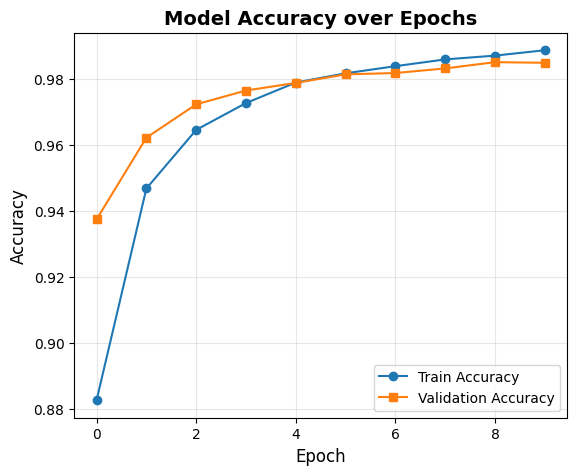

In [5]:
# Plot training history
plt.figure(figsize=(14, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)


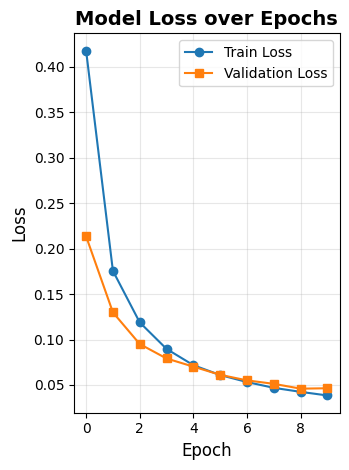

In [6]:
# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Model Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

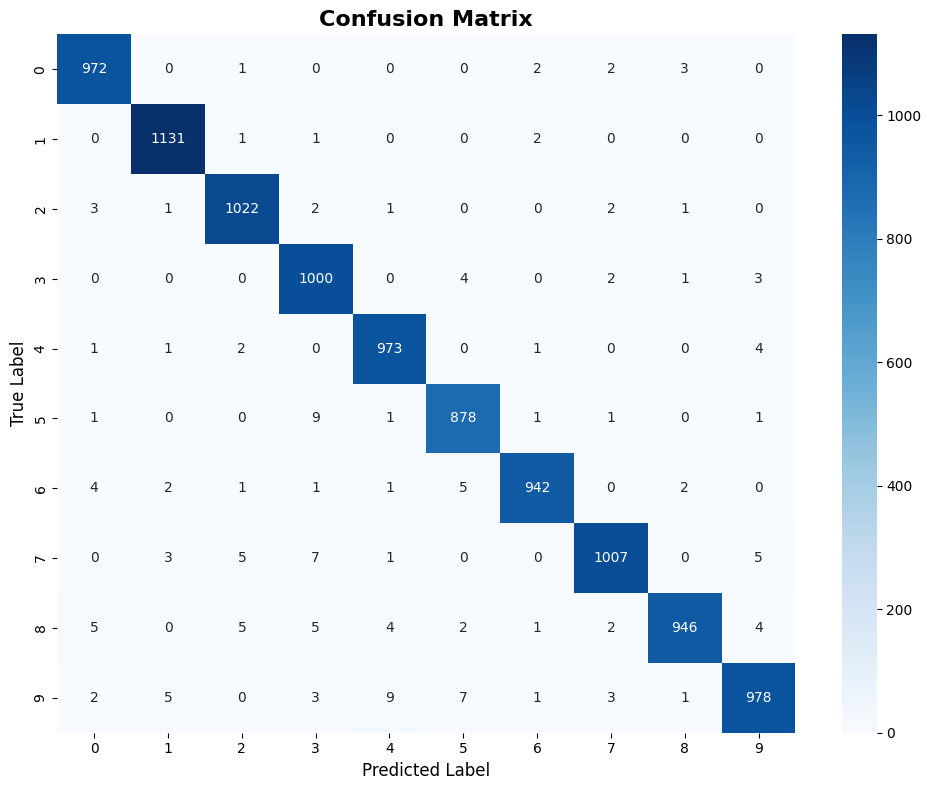

In [7]:
# Generate predictions for confusion matrix
y_pred = lenet.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

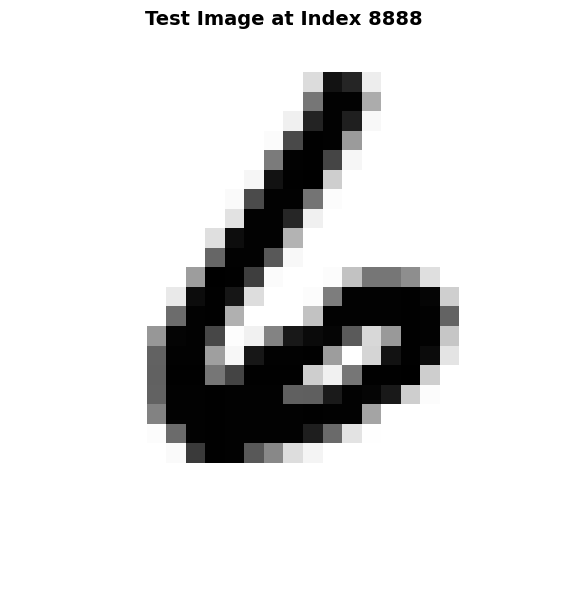

In [8]:
# Test prediction on a sample image
x_train = x_train.reshape(x_train.shape[0], 28, 28)
x_test = x_test.reshape(x_test.shape[0], 28, 28)
image_index = 8888
plt.figure(figsize=(6, 6))
plt.imshow(x_test[image_index].reshape(28, 28), cmap='Greys')
plt.title(f'Test Image at Index {image_index}', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# Make prediction
pred = lenet.predict(x_test[image_index].reshape(1, rows, cols, 1), verbose=0)
predicted_digit = pred.argmax()
actual_digit = y_test_labels[image_index]

print(f'\nPredicted Digit: {predicted_digit}')
print(f'Actual Digit: {actual_digit}')
print(f'Prediction Confidence: {pred[0][predicted_digit]:.4f}')


Predicted Digit: 6
Actual Digit: 6
Prediction Confidence: 0.9994
